Plotting of trajs

In [ ]:
import os
import sys

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from data_collection.data_utils import load_npz

# Load NN data
nn5_data = load_npz("data/2026-02-22_17-17-43_Pendulum_NN_H5/2026-02-22_17-17-43_logs.npz")
nn2_data = load_npz("data/2026-02-22_17-35-42_Pendulum_NN_H2/2026-02-22_17-35-42_logs.npz")

# Load multiple MPC datasets (starting with 10_)
mpc_data_5 = load_npz("data/2026-02-22_17-15-49_Pendulum_H5/2026-02-22_17-15-49_logs.npz")
mpc_data_10 = load_npz("data/2026-02-22_17-34-58_Pendulum_H10/2026-02-22_17-34-58_logs.npz")
mpc_data_100 = load_npz("data/2026-02-22_17-14-00_Pendulum_H100/2026-02-22_17-14-00_logs.npz")  # Example for a second MPC dataset

# Extract qpos and qvel trajectories from both MPC datasets
mpc_qpos_traj_5 = mpc_data_5["default"]["qpos_traj"]
mpc_qvel_traj_5 = mpc_data_5["default"]["qvel_traj"]

mpc_qpos_traj_10 = mpc_data_10["default"]["qpos_traj"]
mpc_qvel_traj_10 = mpc_data_10["default"]["qvel_traj"]

mpc_qpos_traj_100 = mpc_data_100["default"]["qpos_traj"]
mpc_qvel_traj_100 = mpc_data_100["default"]["qvel_traj"]

# Extract NN trajectories
nn_qpos_traj_5 = nn5_data["default"]["qpos_traj"]
nn_qvel_traj_5 = nn5_data["default"]["qvel_traj"]

nn_qpos_traj_2 = nn2_data["default"]["qpos_traj"]
nn_qvel_traj_2 = nn2_data["default"]["qvel_traj"]

# Remove last singleton dim (assuming we're only interested in the 0th dimension)
mpc_qpos_5 = mpc_qpos_traj_5[:, :, 0]  # (T, H_mpc)
mpc_qvel_5 = mpc_qvel_traj_5[:, :, 0]

mpc_qpos_10 = mpc_qpos_traj_10[:, :, 0]  # (T, H_mpc)
mpc_qvel_10 = mpc_qvel_traj_10[:, :, 0]

mpc_qpos_100 = mpc_qpos_traj_100[:, :, 0]  # (T, H_mpc)
mpc_qvel_100 = mpc_qvel_traj_100[:, :, 0]

nn_qpos_5 = nn_qpos_traj_5[:, :, 0]  # (T, H_nn)
nn_qvel_5 = nn_qvel_traj_5[:, :, 0]

nn_qpos_2 = nn_qpos_traj_2[:, :, 0]  # (T, H_nn)
nn_qvel_2 = nn_qvel_traj_2[:, :, 0]

# Set time steps and horizons
T = min(mpc_qpos_5.shape[0], mpc_qpos_10.shape[0], mpc_qpos_100.shape[0], nn_qpos_5.shape[0], nn_qpos_2.shape[0])  # safety
H_mpc_5 = mpc_qpos_5.shape[1] - 1  # Horizon length for MPC dataset 5
H_mpc_10 = mpc_qpos_10.shape[1] - 1  # Horizon length for MPC dataset 10
H_mpc_100 = mpc_qpos_100.shape[1] - 1 # Horizon length for MPC dataset 100
H_nn_5 = nn_qpos_5.shape[1] - 1  # Horizon length for NN
H_nn_2 = nn_qpos_2.shape[1] - 1  # Horizon length for NN

# ---- figure setup ----
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlabel("q")
ax.set_ylabel("q_dot")
ax.set_title("MPC vs MPC + NN")

# Axis limits across BOTH datasets
ax.set_xlim(-3.142, 3.142)
ax.set_ylim(-5.0, 5.0)

ax.grid(True)
# ax.set_aspect('equal', adjustable='box')

# Lines for multiple MPC datasets
mpc_line_5, = ax.plot([], [], color='purple', marker='.', lw=2, markersize=3, label=f"MPC 5 (H={H_mpc_5})", alpha=0.3)
mpc_line_10, = ax.plot([], [], color='blue', marker='.', lw=2, markersize=3, label=f"MPC 10 (H={H_mpc_10})", alpha=0.3)
mpc_line_100, = ax.plot([], [], color='green', marker='.', lw=2, markersize=3, label=f"MPC 100 (H={H_mpc_100})", alpha=0.3)
nn_line_2, = ax.plot([], [], color='orange', marker='.', lw=2, markersize=3, label=f"NN 2 (H={H_nn_2})", alpha=0.3)
nn_line_5, = ax.plot([], [], color='red', marker='.', lw=2, markersize=3, label=f"NN 5 (H={H_nn_5})", alpha=0.3)

# Current points
mpc_point_5, = ax.plot([], [], color='purple', markersize=10, marker='s')
mpc_point_10, = ax.plot([], [], color='blue', markersize=10, marker='p')
mpc_point_100, = ax.plot([], [], color='green', markersize=10, marker='^')
nn_point_5, = ax.plot([], [], color='red', markersize=10, marker='d')
nn_point_2, = ax.plot([], [], color='orange', markersize=10, marker='o')

ax.legend()

# Update function for animation
def update(t):
    # MPC dataset 5
    mpc_line_5.set_data(mpc_qpos_5[t], mpc_qvel_5[t])
    mpc_point_5.set_data([mpc_qpos_5[t, 0]], [mpc_qvel_5[t, 0]])

    # MPC dataset 10
    mpc_line_10.set_data(mpc_qpos_10[t], mpc_qvel_10[t])
    mpc_point_10.set_data([mpc_qpos_10[t, 0]], [mpc_qvel_10[t, 0]])

    # MPC dataset 100
    mpc_line_100.set_data(mpc_qpos_100[t], mpc_qvel_100[t])
    mpc_point_100.set_data([mpc_qpos_100[t, 0]], [mpc_qvel_100[t, 0]])

    # NN horizon (longer)
    nn_line_5.set_data(nn_qpos_5[t], nn_qvel_5[t])
    nn_point_5.set_data([nn_qpos_5[t, 0]], [nn_qvel_5[t, 0]])
    nn_line_2.set_data(nn_qpos_2[t], nn_qvel_2[t])
    nn_point_2.set_data([nn_qpos_2[t, 0]], [nn_qvel_2[t, 0]])

    return mpc_line_5, mpc_point_5, mpc_line_10, mpc_point_10, mpc_line_100, mpc_point_100, nn_line_5, nn_point_5, nn_line_2, nn_point_2

# Animation setup
ani = FuncAnimation(fig, update, frames=T, interval=60, blit=True)

# # Display animation in Jupyter notebook
# from IPython.display import HTML
# HTML(ani.to_jshtml())

ani.save("pendulum_animation.mp4", writer="ffmpeg", fps=30, dpi=400)

Current working directory: /Users/nicodemussoh/Documents/mpc_MuJoCo

Loaded file: data/2026-02-22_17-35-42_Pendulum_NN_H2/2026-02-22_17-35-42_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj']


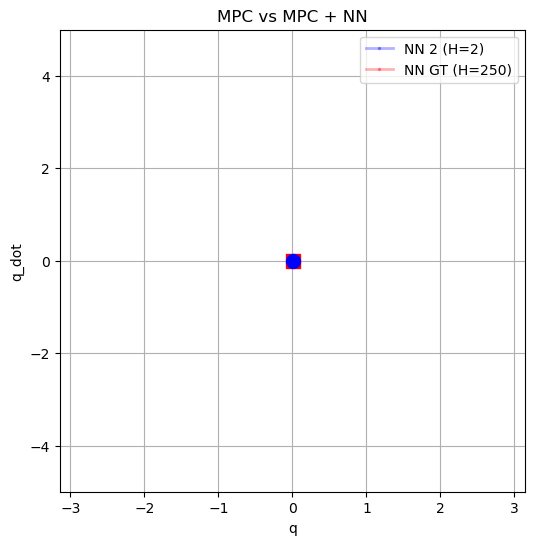

In [8]:
import os
import sys

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from data_collection.data_utils import load_npz

# Load NN data
nn2_data = load_npz("data/2026-02-22_17-35-42_Pendulum_NN_H2/2026-02-22_17-35-42_logs.npz")

# Extract qpos and qvel trajectories from both MPC datasets
mpc_qpos_traj_GT = nn2_data["default"]["GT_qpos_traj"]
mpc_qvel_traj_GT = nn2_data["default"]["GT_qvel_traj"]

nn_qpos_traj_2 = nn2_data["default"]["qpos_traj"]
nn_qvel_traj_2 = nn2_data["default"]["qvel_traj"]

# Remove last singleton dim (assuming we're only interested in the 0th dimension)
mpc_qpos_GT = mpc_qpos_traj_GT[:, :, 0]  # (T, H_mpc)
mpc_qvel_GT = mpc_qvel_traj_GT[:, :, 0]

nn_qpos_2 = nn_qpos_traj_2[:, :, 0]  # (T, H_nn)
nn_qvel_2 = nn_qvel_traj_2[:, :, 0]

# Set time steps and horizons
T = min(mpc_qpos_GT.shape[0], nn_qpos_2.shape[0])  # safety
H_mpc_GT = mpc_qpos_GT.shape[1] - 1  # Horizon length for MPC dataset GT
H_nn_2 = nn_qpos_2.shape[1] - 1  # Horizon length for NN
H_nn_2 = nn_qpos_2.shape[1] - 1  # Horizon length for NN

# ---- figure setup ----
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlabel("q")
ax.set_ylabel("q_dot")
ax.set_title("MPC vs MPC + NN")

# Axis limits across BOTH datasets
ax.set_xlim(-3.142, 3.142)
ax.set_ylim(-5.0, 5.0)

ax.grid(True)
# ax.set_aspect('equal', adjustable='box')

# Lines for multiple MPC datasets
nn_line_2, = ax.plot([], [], color='blue', marker='.', lw=2, markersize=3, label=f"NN 2 (H={H_nn_2})", alpha=0.3)
mpc_line_GT, = ax.plot([], [], color='red', marker='.', lw=2, markersize=3, label="NN GT (H=250)", alpha=0.3)

# Current points
mpc_point_GT, = ax.plot([], [], color='red', markersize=10, marker='s')
nn_point_2, = ax.plot([], [], color='blue', markersize=10, marker='o')

ax.legend()

# Update function for animation
def update(t):
    # MPC dataset GT
    mpc_line_GT.set_data(mpc_qpos_GT[t], mpc_qvel_GT[t])
    mpc_point_GT.set_data([mpc_qpos_GT[t, 0]], [mpc_qvel_GT[t, 0]])

    # NN horizon (longer)
    nn_line_2.set_data(nn_qpos_2[t], nn_qvel_2[t])
    nn_point_2.set_data([nn_qpos_2[t, 0]], [nn_qvel_2[t, 0]])

    return mpc_line_GT, mpc_point_GT, nn_line_2, nn_point_2

# Animation setup
ani = FuncAnimation(fig, update, frames=T, interval=60, blit=True)

# # Display animation in Jupyter notebook
# from IPython.display import HTML
# HTML(ani.to_jshtml())

ani.save("pendulum_animation.mp4", writer="ffmpeg", fps=30, dpi=400)

Current working directory: /Users/nicodemussoh/Documents/mpc_MuJoCo

Loaded file: data/2026-02-22_17-35-42_Pendulum_NN_H2/2026-02-22_17-35-42_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj']


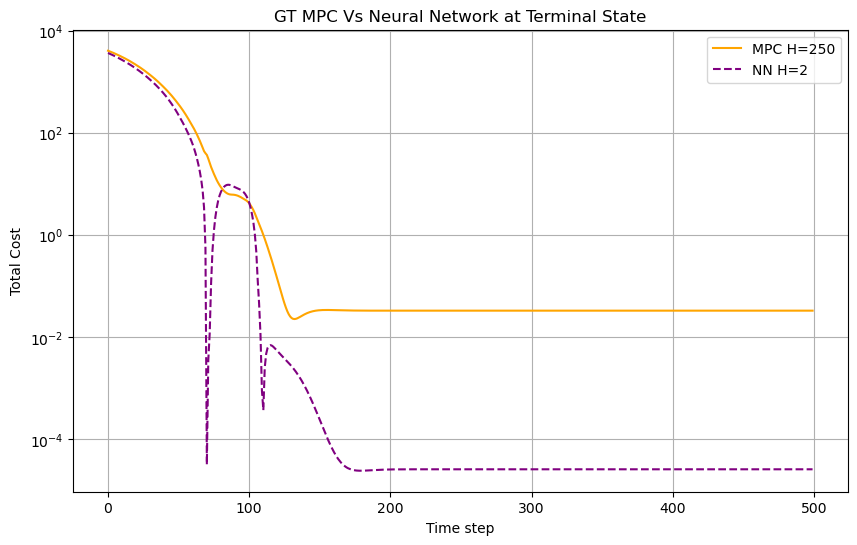

In [5]:
import os
import sys
import numpy as np

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Plot cost graph over time
import matplotlib.pyplot as plt
from data_collection.data_utils import load_npz

# Load NN data
nn2_data = load_npz("data/2026-02-22_17-35-42_Pendulum_NN_H2/2026-02-22_17-35-42_logs.npz")

# Extract total_cost arrays
nn2_cost = nn2_data["default"]["terminal_cost"]
GT_mpc_cost = nn2_data["default"]["GT_cost"]

# Create a time vector for each (assume uniform 1 step per time step)
t_GT_mpc = np.arange(len(GT_mpc_cost))
t_nn2 = np.arange(len(nn2_cost))

# Plot
plt.figure(figsize=(10, 6))

plt.plot(t_GT_mpc, GT_mpc_cost, label="MPC H=250", color="orange")
plt.plot(t_nn2, nn2_cost, label="NN H=2", linestyle="--", color="purple")

plt.xlabel("Time step")
plt.ylabel("Total Cost")
plt.yscale("log")
plt.title("GT MPC Vs Neural Network at Terminal State")
plt.legend()
plt.grid(True)
plt.show()


Loaded file: data/2026-02-22_17-35-42_Pendulum_NN_H2/2026-02-22_17-35-42_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj']


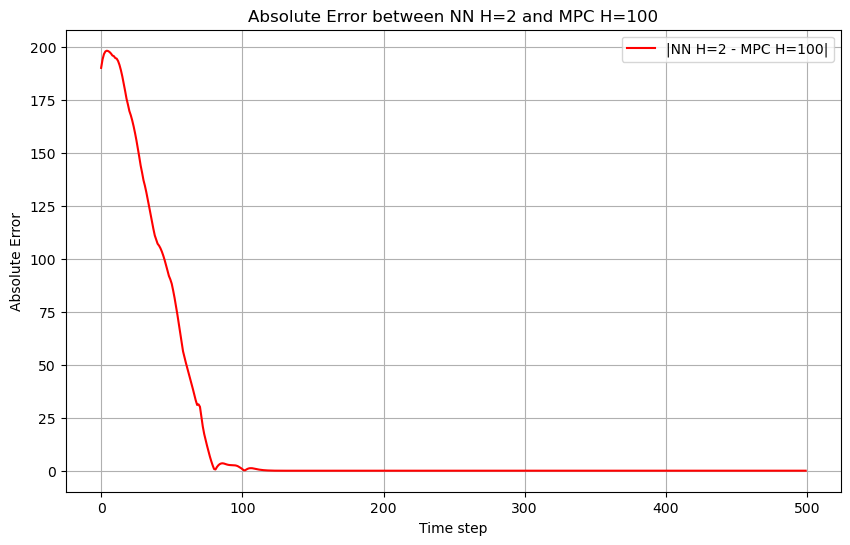

In [2]:
# Plot absolute error between NN H=2 and MPC H=100
import numpy as np
import matplotlib.pyplot as plt
from data_collection.data_utils import load_npz

# Load NN data
nn2_data = load_npz("data/2026-02-22_17-35-42_Pendulum_NN_H2/2026-02-22_17-35-42_logs.npz")
GT_mpc_cost = nn2_data["default"]["GT_cost"]
nn2_cost = nn2_data["default"]["total_cost"]

# Make sure the arrays are the same length (truncate to the shorter one)
T = min(len(nn2_cost), len(GT_mpc_cost))
abs_error = np.abs(nn2_cost[:T] - GT_mpc_cost[:T])

# Time vector
t = np.arange(T)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, abs_error, color="red", label="|NN H=2 - MPC H=100|")

plt.xlabel("Time step")
plt.ylabel("Absolute Error")
plt.title("Absolute Error between NN H=2 and MPC H=100")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Run in a .py file to save the figure

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from neural_network.models import MODEL_REGISTRY

matplotlib.use("TkAgg")  # Keep only if running as a script (NOT in Jupyter)

# =========================
# USER SETTINGS
# =========================

ANGLE_MIN, ANGLE_MAX = -np.pi, np.pi
ANGVEL_MIN, ANGVEL_MAX = -5.0, 5.0
NUM_POINTS = 100


# =========================
# LOAD MODEL
# =========================

model = MODEL_REGISTRY["PendulumModel"](None)
model.load_state_dict(torch.load(
    "value_iteration/output/2026-02-21_22-11-41_Pendulum_VI_converged/loop_400/training/model_epoch_14.pt",
    map_location="cpu"
))
model.eval()


# =========================
# CREATE INPUT GRID
# =========================

angles = np.linspace(ANGLE_MIN, ANGLE_MAX, NUM_POINTS)
ang_vels = np.linspace(ANGVEL_MIN, ANGVEL_MAX, NUM_POINTS)

A, W = np.meshgrid(angles, ang_vels)

inputs = np.stack([A.ravel(), W.ravel()], axis=1)
inputs_torch = torch.tensor(inputs, dtype=torch.float32)


# =========================
# RUN MODEL
# =========================

with torch.no_grad():
    costs = model(inputs_torch).cpu().numpy()

C = costs.reshape(NUM_POINTS, NUM_POINTS)


# =========================
# 2D CONTOUR PLOT
# =========================

plt.figure(figsize=(8, 6))

# Filled contours
contour_filled = plt.contourf(
    A, W, C,
    levels=50,
    cmap="viridis"
)

# Optional: contour lines on top
contour_lines = plt.contour(
    A, W, C,
    levels=20,
    colors="black",
    linewidths=0.5
)

plt.clabel(contour_lines, inline=True, fontsize=8)

plt.xlabel("Angle (rad)")
plt.ylabel("Angular Velocity (rad/s)")
plt.title("Neural Network Cost Landscape")
plt.colorbar(contour_filled, label="Cost")

plt.tight_layout()
plt.show()